In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/raw")

files = [
    "DEMO_L",
    "BMX_L",
    "BPXO_L",
    "VID_L",
    "HDL_L",
    "TRIGLY_L",
    "SMQ_L",
]

for file in files:
    path = DATA_DIR / f"{file}.XPT"
    df = pd.read_sas(path)

    print(f"{file}: {df.shape}")

DEMO_L: (11933, 27)
BMX_L: (8860, 22)
BPXO_L: (7801, 12)
VID_L: (8727, 10)
HDL_L: (8068, 4)
TRIGLY_L: (3996, 10)
SMQ_L: (9015, 9)


In [4]:
demo = pd.read_sas(DATA_DIR / "DEMO_L.XPT")
bmx = pd.read_sas(DATA_DIR / "BMX_L.XPT")
bpx = pd.read_sas(DATA_DIR / "BPXO_L.XPT")
vid = pd.read_sas(DATA_DIR / "VID_L.XPT")
hdl = pd.read_sas(DATA_DIR / "HDL_L.XPT")
trigly = pd.read_sas(DATA_DIR / "TRIGLY_L.XPT")
smq = pd.read_sas(DATA_DIR / "SMQ_L.XPT")

In [5]:
for name, df in {
    "DEMO": demo,
    "BMX": bmx,
    "BPXO": bpx,
    "VID": vid,
    "HDL": hdl,
    "TRIGLY": trigly,
    "SMQ": smq,
}.items():
    print(f"\n{name}")
    print(df.shape)
    print(df.columns.tolist())


DEMO
(11933, 27)
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR']

BMX
(8860, 22)
['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']

BPXO
(7801, 12)
['SEQN', 'BPAOARM', 'BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3']

VID
(8727, 10)
['SEQN', 'WTPH2YR', 'LBXVIDMS', 'LBDVIDLC', 'LBXVD2MS', 'LBDVD2LC', 'LBXVD3MS', 'LBDVD3LC', 'LBXVE3MS', 'LBDVE3LC']

HDL
(8068, 4)
['SEQN', 'WTPH2YR', 'LBDHDD', 'LBDHDDSI']

TRIGLY
(3996, 10)
['SEQN', 'WTSAF2YR', 'LBXTLG', 'LBDTRSI', 'LBDLDL', 'LBD

In [6]:
datasets = {
    "DEMO": demo,
    "BMX": bmx,
    "BPXO": bpx,
    "VID": vid,
    "HDL": hdl,
    "TRIGLY": trigly,
    "SMQ": smq
}

for name, df in datasets.items():
    print(
        f"{name:8} | "
        f"rows = {len(df):5} | "
        f"unique SEQN = {df['SEQN'].nunique():5}"
    )

DEMO     | rows = 11933 | unique SEQN = 11933
BMX      | rows =  8860 | unique SEQN =  8860
BPXO     | rows =  7801 | unique SEQN =  7801
VID      | rows =  8727 | unique SEQN =  8727
HDL      | rows =  8068 | unique SEQN =  8068
TRIGLY   | rows =  3996 | unique SEQN =  3996
SMQ      | rows =  9015 | unique SEQN =  9015


In [7]:
for name, df in datasets.items():
    print(
        name,
        "duplicated SEQN:",
        df["SEQN"].duplicated().sum()
    )

DEMO duplicated SEQN: 0
BMX duplicated SEQN: 0
BPXO duplicated SEQN: 0
VID duplicated SEQN: 0
HDL duplicated SEQN: 0
TRIGLY duplicated SEQN: 0
SMQ duplicated SEQN: 0


In [8]:
selected_columns = {
    "DEMO": [
        "SEQN",
        "RIAGENDR",
        "RIDAGEYR",
        "RIDRETH3",
        "DMDEDUC2",
        "DMDMARTZ",
        "DMDHHSIZ",
        "INDFMPIR",
        "WTINT2YR",
        "WTMEC2YR",
        "SDMVSTRA",
        "SDMVPSU",
    ],

    "BMX": [
        "SEQN",
        "BMXWT",
        "BMXHT",
        "BMXBMI",
        "BMXWAIST",
    ],

    "BPXO": [
        "SEQN",
        "BPXOSY1",
        "BPXOSY2",
        "BPXOSY3",
        "BPXODI1",
        "BPXODI2",
        "BPXODI3",
    ],

    "VID": [
        "SEQN",
        "LBXVIDMS",
        "LBDVIDLC",
    ],

    "HDL": [
        "SEQN",
        "LBDHDD",
    ],

    "TRIGLY": [
        "SEQN",
        "LBXTLG",
        "LBDLDL",
    ],

    "SMQ": [
        "SEQN",
        "SMQ020",
        "SMQ040",
        "SMD641",
        "SMD650",
        "SMD630",
    ],
}

In [9]:
rename_map = {
    "SEQN": "participant_id",

    "RIAGENDR": "gender",
    "RIDAGEYR": "age",
    "RIDRETH3": "race_ethnicity",
    "DMDEDUC2": "education_level",
    "DMDMARTZ": "marital_status",
    "DMDHHSIZ": "household_size",
    "INDFMPIR": "family_income_poverty_ratio",

    "WTINT2YR": "interview_weight",
    "WTMEC2YR": "exam_weight",
    "SDMVSTRA": "survey_stratum",
    "SDMVPSU": "survey_psu",

    "BMXWT": "weight",
    "BMXHT": "height",
    "BMXBMI": "bmi",
    "BMXWAIST": "waist_circumference",

    "BPXOSY1": "systolic_bp_1",
    "BPXOSY2": "systolic_bp_2",
    "BPXOSY3": "systolic_bp_3",

    "BPXODI1": "diastolic_bp_1",
    "BPXODI2": "diastolic_bp_2",
    "BPXODI3": "diastolic_bp_3",

    "LBXVIDMS": "vitamin_d",
    "LBDVIDLC": "vitamin_d_detection_flag",

    "LBDHDD": "hdl",

    "LBXTLG": "triglycerides",
    "LBDLDL": "ldl",

    "SMQ020": "smoked_100_cigarettes",
    "SMQ040": "current_smoking_status",
    "SMD641": "smoking_days_30d",
    "SMD650": "cigarettes_per_day",
    "SMD630": "age_started_smoking",
}

In [10]:
categorical_columns = [
    ("DEMO", demo, ["RIAGENDR", "RIDRETH3", "DMDEDUC2", "DMDMARTZ"]),
    ("SMQ", smq, ["SMQ020", "SMQ040"])
]

for dataset_name, df, columns in categorical_columns:
    print(f"\n{'=' * 50}")
    print(dataset_name)

    for col in columns:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False).sort_index())


DEMO

RIAGENDR
RIAGENDR
1.0    5575
2.0    6358
Name: count, dtype: int64

RIDRETH3
RIDRETH3
1.0    1117
2.0    1373
3.0    6217
4.0    1597
6.0     681
7.0     948
Name: count, dtype: int64

DMDEDUC2
DMDEDUC2
1.0     373
2.0     666
3.0    1749
4.0    2370
5.0    2625
9.0      11
NaN    4139
Name: count, dtype: int64

DMDMARTZ
DMDMARTZ
1.0     4136
2.0     2022
3.0     1625
77.0       4
99.0       5
NaN     4141
Name: count, dtype: int64

SMQ

SMQ020
SMQ020
1.0    3243
2.0    4878
7.0       7
9.0       7
NaN     880
Name: count, dtype: int64

SMQ040
SMQ040
1.0     952
2.0     238
3.0    2053
NaN    5772
Name: count, dtype: int64


In [11]:
for name, df in datasets.items():
    print(f"\n{name}")

    missing = (
        df.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print(missing.round(2))


DEMO
RIDAGEMN    96.84
RIDEXPRG    87.40
DMDYRUSR    84.29
DMDHSEDZ    82.18
RIDEXAGM    76.64
DMDHREDZ    68.61
DMDHRMAZ    66.31
DMDHRGND    65.52
DMDHRAGZ    65.44
DMDMARTZ    34.70
DMDEDUC2    34.69
DMQMILIZ    30.44
RIDEXMON    25.75
INDFMPIR    17.10
DMDBORN4     0.16
SDDSRVYR     0.00
SEQN         0.00
RIDSTATR     0.00
RIDRETH1     0.00
RIDRETH3     0.00
RIAGENDR     0.00
RIDAGEYR     0.00
DMDHHSIZ     0.00
WTINT2YR     0.00
WTMEC2YR     0.00
SDMVSTRA     0.00
SDMVPSU      0.00
dtype: float64

BMX
BMIHEAD     100.00
BMIRECUM     99.80
BMXHEAD      99.21
BMIHT        98.49
BMIARML      97.74
BMIARMC      97.69
BMIWT        96.11
BMIWAIST     96.08
BMIHIP       95.93
BMILEG       95.53
BMXRECUM     94.88
BMDBMIC      71.87
BMXHIP       23.52
BMXLEG       17.21
BMXWAIST      7.56
BMXBMI        4.39
BMXHT         4.07
BMXARMC       3.36
BMXARML       3.30
BMXWT         1.20
SEQN          0.00
BMDSTATS      0.00
dtype: float64

BPXO
BPXODI3     4.11
BPXOPLS3    4.11
BPXOSY3     4.1

In [12]:
adult_demo = demo[demo["RIDAGEYR"] >= 18].copy()

print("Total participants:", len(demo))
print("Adults (18+):", len(adult_demo))

cols_to_check = [
    "RIAGENDR",
    "RIDAGEYR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
    "DMDHHSIZ",
    "INDFMPIR",
]

missing_adults = (
    adult_demo[cols_to_check]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nMissingness among adults:")
print(missing_adults.round(2))

Total participants: 11933
Adults (18+): 8153

Missingness among adults:
INDFMPIR    17.00
DMDMARTZ     4.43
DMDEDUC2     4.40
RIDRETH3     0.00
RIDAGEYR     0.00
RIAGENDR     0.00
DMDHHSIZ     0.00
dtype: float64


In [13]:
for col in [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
]:
    print(f"\n{'=' * 40}")
    print(col)
    print(adult_demo[col].value_counts(dropna=False).sort_index())


RIAGENDR
RIAGENDR
1.0    3657
2.0    4496
Name: count, dtype: int64

RIDRETH3
RIDRETH3
1.0     598
2.0     819
3.0    4704
4.0    1045
6.0     443
7.0     544
Name: count, dtype: int64

DMDEDUC2
DMDEDUC2
1.0     373
2.0     666
3.0    1749
4.0    2370
5.0    2625
9.0      11
NaN     359
Name: count, dtype: int64

DMDMARTZ
DMDMARTZ
1.0     4136
2.0     2022
3.0     1625
77.0       4
99.0       5
NaN      361
Name: count, dtype: int64


In [14]:
categorical_cols = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
]

for col in categorical_cols:
    print(f"\n{'=' * 50}")
    print(col)

    counts = (
        adult_demo[col]
        .value_counts(dropna=False)
        .sort_index()
    )

    print(counts.to_string())


RIAGENDR
RIAGENDR
1.0    3657
2.0    4496

RIDRETH3
RIDRETH3
1.0     598
2.0     819
3.0    4704
4.0    1045
6.0     443
7.0     544

DMDEDUC2
DMDEDUC2
1.0     373
2.0     666
3.0    1749
4.0    2370
5.0    2625
9.0      11
NaN     359

DMDMARTZ
DMDMARTZ
1.0     4136
2.0     2022
3.0     1625
77.0       4
99.0       5
NaN      361


In [15]:
smoking_cols = [
    "SMQ020",
    "SMQ040",
    "SMD641",
    "SMD650",
    "SMD630",
]

for col in smoking_cols:
    print(f"\n{'=' * 50}")
    print(col)

    counts = (
        smq[col]
        .value_counts(dropna=False)
        .sort_index()
    )

    print(counts.to_string())


SMQ020
SMQ020
1.0    3243
2.0    4878
7.0       7
9.0       7
NaN     880

SMQ040
SMQ040
1.0     952
2.0     238
3.0    2053
NaN    5772

SMD641
SMD641
5.397605e-79      23
1.000000e+00      14
2.000000e+00      24
3.000000e+00      21
4.000000e+00       7
5.000000e+00       9
6.000000e+00       7
7.000000e+00       3
8.000000e+00       9
1.000000e+01      30
1.200000e+01      12
1.400000e+01       3
1.500000e+01      35
1.700000e+01       1
1.800000e+01       1
2.000000e+01      39
2.200000e+01       2
2.300000e+01       1
2.500000e+01       9
2.700000e+01       2
2.800000e+01       2
2.900000e+01       1
3.000000e+01      13
9.900000e+01       5
NaN             8742

SMD650
SMD650
1.0        94
2.0        86
3.0        54
4.0        56
5.0        98
6.0        56
7.0        45
8.0        30
9.0         4
10.0      217
11.0        5
12.0       38
13.0        2
15.0       87
16.0        6
17.0        1
18.0        4
20.0      205
21.0        1
24.0        2
25.0       14
26.0        1

In [16]:
adult_demo = demo[demo["RIDAGEYR"] >= 18].copy()

In [17]:
adult_demo["DMDEDUC2"] = adult_demo["DMDEDUC2"].replace({
    7: np.nan,
    9: np.nan
})

adult_demo["DMDMARTZ"] = adult_demo["DMDMARTZ"].replace({
    7: np.nan,
    9: np.nan
})

In [18]:
smq_clean = smq.copy()

smq_clean["SMQ020"] = smq_clean["SMQ020"].replace({
    7: np.nan,
    9: np.nan
})

In [19]:
print(smq["SMD641"].dropna().unique()[:30])

[1.70000000e+01 1.00000000e+01 7.00000000e+00 1.50000000e+01
 5.39760535e-79 8.00000000e+00 3.00000000e+01 2.00000000e+01
 1.40000000e+01 2.50000000e+01 4.00000000e+00 2.00000000e+00
 3.00000000e+00 1.00000000e+00 6.00000000e+00 1.20000000e+01
 5.00000000e+00 2.70000000e+01 9.90000000e+01 1.80000000e+01
 2.80000000e+01 2.30000000e+01 2.20000000e+01 2.90000000e+01]


In [20]:
smq_clean = smq.copy()

smq_clean["SMD641"] = smq_clean["SMD641"].replace(
    5.39760535e-79,
    0
)

In [21]:
gender_map = {
    1: "Male",
    2: "Female"
}

race_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other Race / Multiracial"
}

education_map = {
    1: "Less than 9th grade",
    2: "9th-11th grade",
    3: "High school graduate / GED",
    4: "Some college / AA",
    5: "College graduate or above"
}

marital_map = {
    1: "Married / Living with partner",
    2: "Widowed / Divorced / Separated",
    3: "Never married"
}

In [22]:
adult_demo["gender"] = adult_demo["RIAGENDR"].map(gender_map)
adult_demo["race_ethnicity"] = adult_demo["RIDRETH3"].map(race_map)
adult_demo["education_level"] = adult_demo["DMDEDUC2"].map(education_map)
adult_demo["marital_status"] = adult_demo["DMDMARTZ"].map(marital_map)

In [23]:
print(adult_demo[
    ["RIAGENDR", "gender",
     "RIDRETH3", "race_ethnicity",
     "DMDEDUC2", "education_level",
     "DMDMARTZ", "marital_status"]
].head(10))

    RIAGENDR  gender  RIDRETH3      race_ethnicity  DMDEDUC2  \
0        1.0    Male       6.0  Non-Hispanic Asian       5.0   
1        1.0    Male       3.0  Non-Hispanic White       5.0   
2        2.0  Female       2.0      Other Hispanic       3.0   
6        1.0    Male       1.0    Mexican American       2.0   
7        2.0  Female       3.0  Non-Hispanic White       3.0   
8        1.0    Male       1.0    Mexican American       4.0   
9        2.0  Female       3.0  Non-Hispanic White       5.0   
10       2.0  Female       4.0  Non-Hispanic Black       4.0   
11       1.0    Male       3.0  Non-Hispanic White       5.0   
12       2.0  Female       3.0  Non-Hispanic White       3.0   

               education_level  DMDMARTZ                 marital_status  
0    College graduate or above       1.0  Married / Living with partner  
1    College graduate or above       1.0  Married / Living with partner  
2   High school graduate / GED       1.0  Married / Living with partner  

In [24]:
smq_clean["SMQ020"] = smq_clean["SMQ020"].replace({
    7: np.nan,
    9: np.nan
})

smq_clean["SMD641"] = smq_clean["SMD641"].replace({
    77: np.nan,
    99: np.nan
})

smq_clean["SMD650"] = smq_clean["SMD650"].replace({
    777: np.nan,
    999: np.nan
})

smq_clean["SMD630"] = smq_clean["SMD630"].replace({
    777: np.nan,
    999: np.nan
})

In [25]:
bmx_selected = bmx[
    [
        "SEQN",
        "BMXWT",
        "BMXHT",
        "BMXBMI",
        "BMXWAIST"
    ]
].copy()

bpx_selected = bpx[
    [
        "SEQN",
        "BPXOSY1",
        "BPXOSY2",
        "BPXOSY3",
        "BPXODI1",
        "BPXODI2",
        "BPXODI3"
    ]
].copy()

smq_selected = smq_clean[
    [
        "SEQN",
        "SMQ020",
        "SMQ040",
        "SMD641",
        "SMD650",
        "SMD630"
    ]
].copy()

In [26]:
base = adult_demo.merge(
    bmx_selected,
    on="SEQN",
    how="left"
)

base = base.merge(
    bpx_selected,
    on="SEQN",
    how="left"
)

base = base.merge(
    smq_selected,
    on="SEQN",
    how="left"
)

print("Base dataset shape:", base.shape)
print("Unique participants:", base["SEQN"].nunique())

Base dataset shape: (8153, 46)
Unique participants: 8153


In [27]:
for col in [
    "BMXBMI",
    "BMXWAIST",
    "BPXOSY1",
    "BPXOSY2",
    "BPXOSY3",
    "BPXODI1",
    "BPXODI2",
    "BPXODI3",
    "SMQ020",
    "SMQ040"
]:
    missing = base[col].isna().mean() * 100
    print(f"{col:12} : {missing:6.2f}% missing")

BMXBMI       :  23.53% missing
BMXWAIST     :  26.17% missing
BPXOSY1      :  24.90% missing
BPXOSY2      :  24.98% missing
BPXOSY3      :  25.17% missing
BPXODI1      :  24.90% missing
BPXODI2      :  24.98% missing
BPXODI3      :  25.17% missing
SMQ020       :   0.39% missing
SMQ040       :  60.22% missing


In [28]:
base["bmi_missing"] = base["BMXBMI"].isna()

print(
    base.groupby("bmi_missing")[
        ["RIDAGEYR", "DMDHHSIZ", "INDFMPIR"]
    ].mean()
)

              RIDAGEYR  DMDHHSIZ  INDFMPIR
bmi_missing                               
False        52.295108  2.630473  2.904411
True         51.654327  2.596455  2.738229


In [29]:
print(
    base.groupby("bmi_missing")["RIAGENDR"]
    .value_counts(normalize=True)
)

bmi_missing  RIAGENDR
False        2.0         0.548196
             1.0         0.451804
True         2.0         0.562044
             1.0         0.437956
Name: proportion, dtype: float64


In [30]:
base["age_group"] = pd.cut(
    base["RIDAGEYR"],
    bins=[17, 29, 39, 49, 59, 69, 79, 100],
    labels=[
        "18-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80+"
    ]
)

bmi_missing_by_age = (
    base.groupby("age_group", observed=False)["BMXBMI"]
    .apply(lambda x: x.isna().mean() * 100)
)

print(bmi_missing_by_age.round(2))

age_group
18-29    27.32
30-39    24.07
40-49    24.28
50-59    21.88
60-69    17.28
70-79    22.82
80+      38.10
Name: BMXBMI, dtype: float64


In [31]:
bmi_missing_by_gender = (
    base.groupby("gender")["BMXBMI"]
    .apply(lambda x: x.isna().mean() * 100)
)

print(bmi_missing_by_gender.round(2))

gender
Female    23.98
Male      22.97
Name: BMXBMI, dtype: float64


In [32]:
base = base.drop(columns=["age_group"])

In [33]:
systolic_cols = [
    "BPXOSY1",
    "BPXOSY2",
    "BPXOSY3"
]

diastolic_cols = [
    "BPXODI1",
    "BPXODI2",
    "BPXODI3"
]

print("Systolic readings available:")
print(base[systolic_cols].notna().sum(axis=1).value_counts().sort_index())

print("\nDiastolic readings available:")
print(base[diastolic_cols].notna().sum(axis=1).value_counts().sort_index())

Systolic readings available:
0    2030
1       6
2      17
3    6100
Name: count, dtype: int64

Diastolic readings available:
0    2030
1       6
2      17
3    6100
Name: count, dtype: int64


In [34]:
base["systolic_bp"] = base[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].mean(axis=1)

base["diastolic_bp"] = base[
    ["BPXODI1", "BPXODI2", "BPXODI3"]
].mean(axis=1)

In [35]:
print(
    base[
        ["systolic_bp", "diastolic_bp"]
    ].describe()
)

       systolic_bp  diastolic_bp
count  6123.000000   6123.000000
mean    122.411400     74.415728
std      17.999616     11.027268
min      70.000000     34.000000
25%     110.333333     66.666667
50%     120.000000     73.666667
75%     132.000000     81.000000
max     232.333333    139.000000


In [36]:
print(
    base[
        [
            "BPXOSY1",
            "BPXOSY2",
            "BPXOSY3",
            "systolic_bp",
            "BPXODI1",
            "BPXODI2",
            "BPXODI3",
            "diastolic_bp"
        ]
    ].head(10)
)

   BPXOSY1  BPXOSY2  BPXOSY3  systolic_bp  BPXODI1  BPXODI2  BPXODI3  \
0    135.0    131.0    132.0   132.666667     98.0     96.0     94.0   
1    121.0    117.0    113.0   117.000000     84.0     76.0     76.0   
2    111.0    112.0    104.0   109.000000     79.0     80.0     76.0   
3      NaN      NaN      NaN          NaN      NaN      NaN      NaN   
4      NaN      NaN      NaN          NaN      NaN      NaN      NaN   
5    110.0    120.0    115.0   115.000000     72.0     74.0     75.0   
6    143.0    136.0    145.0   141.333333     76.0     74.0     78.0   
7    130.0    128.0    129.0   129.000000     95.0    100.0    104.0   
8    145.0    130.0    124.0   133.000000     76.0     81.0     81.0   
9    113.0    106.0    115.0   111.333333     78.0     78.0     68.0   

   diastolic_bp  
0     96.000000  
1     78.666667  
2     78.333333  
3           NaN  
4           NaN  
5     73.666667  
6     76.000000  
7     99.666667  
8     79.333333  
9     74.666667  


In [37]:
hdl_selected = hdl[
    [
        "SEQN",
        "LBDHDD"
    ]
].copy()

base_lab = base.merge(
    hdl_selected,
    on="SEQN",
    how="left"
)

print("Shape:", base_lab.shape)
print("Unique participants:", base_lab["SEQN"].nunique())

print(
    "\nHDL missing:",
    round(base_lab["LBDHDD"].isna().mean() * 100, 2),
    "%"
)

Shape: (8153, 50)
Unique participants: 8153

HDL missing: 29.88 %


In [38]:
print(
    base_lab["LBDHDD"].describe()
)

count    5717.000000
mean       54.408956
std        14.687686
min        22.000000
25%        44.000000
50%        52.000000
75%        62.000000
max       159.000000
Name: LBDHDD, dtype: float64


In [39]:
base_lab["hdl_missing"] = base_lab["LBDHDD"].isna()

print(
    base_lab.groupby("hdl_missing")[["RIDAGEYR", "DMDHHSIZ", "INDFMPIR"]]
    .mean()
)

print("\nHDL missingness by gender:")
print(
    base_lab.groupby("RIAGENDR")["LBDHDD"]
    .apply(lambda x: x.isna().mean() * 100)
)

print("\nHDL missingness by age group:")

base_lab["age_group"] = pd.cut(
    base_lab["RIDAGEYR"],
    bins=[17, 29, 39, 49, 59, 69, 79, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
)

print(
    base_lab.groupby("age_group", observed=False)["LBDHDD"]
    .apply(lambda x: x.isna().mean() * 100)
)

              RIDAGEYR  DMDHHSIZ  INDFMPIR
hdl_missing                               
False        52.617632  2.623579  2.946059
True         51.033662  2.619869  2.662887

HDL missingness by gender:
RIAGENDR
1.0    29.094887
2.0    30.516014
Name: LBDHDD, dtype: float64

HDL missingness by age group:
age_group
18-29    36.538462
30-39    31.355932
40-49    28.790787
50-59    27.396098
60-69    23.682720
70-79    28.336079
80+      42.857143
Name: LBDHDD, dtype: float64


In [40]:
print(base_lab["LBDHDD"].describe())

print("\nSelected percentiles:")
print(
    base_lab["LBDHDD"]
    .dropna()
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

count    5717.000000
mean       54.408956
std        14.687686
min        22.000000
25%        44.000000
50%        52.000000
75%        62.000000
max       159.000000
Name: LBDHDD, dtype: float64

Selected percentiles:
0.01    30.0
0.05    35.0
0.25    44.0
0.50    52.0
0.75    62.0
0.95    82.0
0.99    99.0
Name: LBDHDD, dtype: float64


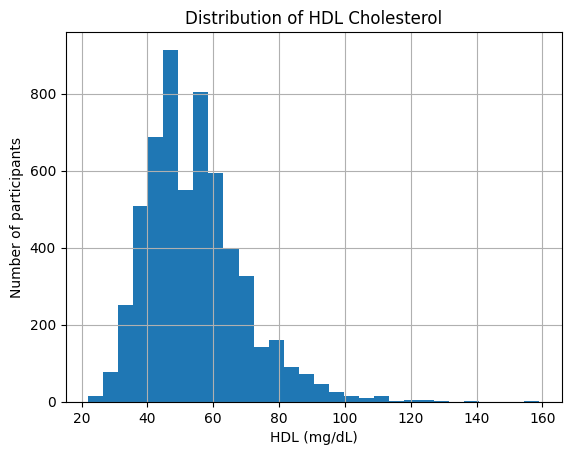

In [41]:
import matplotlib.pyplot as plt
base_lab["LBDHDD"].dropna().hist(bins=30)

plt.xlabel("HDL (mg/dL)")
plt.ylabel("Number of participants")
plt.title("Distribution of HDL Cholesterol")
plt.show()

In [42]:
print(
    base_lab["LBDHDD"]
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)

2428    159.0
7198    138.0
6218    131.0
4914    131.0
7611    127.0
3076    127.0
2066    127.0
1418    123.0
7542    123.0
7890    121.0
6149    121.0
3085    120.0
6348    118.0
4727    116.0
5297    115.0
6189    113.0
1374    113.0
933     112.0
6063    112.0
4424    112.0
Name: LBDHDD, dtype: float64


In [43]:
print("HDL > 100:", (base_lab["LBDHDD"] > 100).sum())
print("HDL > 120:", (base_lab["LBDHDD"] > 120).sum())
print("HDL > 140:", (base_lab["LBDHDD"] > 140).sum())

HDL > 100: 55
HDL > 120: 11
HDL > 140: 1


In [44]:
analysis_df = base_lab[["BMXBMI", "LBDHDD"]].dropna()

print(analysis_df.shape)
print(analysis_df.corr())

(5640, 2)
          BMXBMI    LBDHDD
BMXBMI  1.000000 -0.274561
LBDHDD -0.274561  1.000000


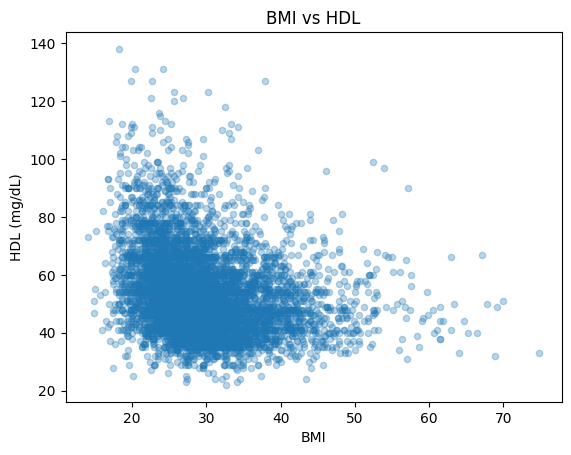

In [45]:
analysis_df.plot(
    x="BMXBMI",
    y="LBDHDD",
    kind="scatter",
    alpha=0.3
)

plt.xlabel("BMI")
plt.ylabel("HDL (mg/dL)")
plt.title("BMI vs HDL")
plt.show()

In [46]:
vid_selected = vid[["SEQN", "LBXVIDMS", "LBDVIDLC"]].copy()

base_lab = base_lab.merge(
    vid_selected,
    on="SEQN",
    how="left"
)

print("Shape:", base_lab.shape)
print("Unique participants:", base_lab["SEQN"].nunique())

print("\nVitamin D missing:")
print(
    round(base_lab["LBXVIDMS"].isna().mean() * 100, 2),
    "%"
)

print("\nVitamin D statistics:")
print(base_lab["LBXVIDMS"].describe())

Shape: (8153, 54)
Unique participants: 8153

Vitamin D missing:
28.57 %

Vitamin D statistics:
count    5824.000000
mean       80.919717
std        37.888941
min         9.130000
25%        54.575000
50%        76.100000
75%       100.000000
max       424.000000
Name: LBXVIDMS, dtype: float64


In [47]:
print(
    base_lab["LBXVIDMS"]
    .dropna()
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

0.01     18.146
0.05     29.000
0.25     54.575
0.50     76.100
0.75    100.000
0.95    151.000
0.99    196.770
Name: LBXVIDMS, dtype: float64


In [48]:
print(
    base_lab["LBXVIDMS"]
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)

print("\nVitamin D > 200:", (base_lab["LBXVIDMS"] > 200).sum())
print("Vitamin D > 300:", (base_lab["LBXVIDMS"] > 300).sum())
print("Vitamin D > 400:", (base_lab["LBXVIDMS"] > 400).sum())

85      424.0
7832    292.0
4151    290.0
6111    285.0
5116    282.0
1084    281.0
7432    277.0
3401    277.0
6032    264.0
3246    241.0
5996    239.0
2640    236.0
1164    235.0
919     232.0
1589    231.0
747     231.0
5743    229.0
7712    229.0
7895    229.0
3185    229.0
Name: LBXVIDMS, dtype: float64

Vitamin D > 200: 49
Vitamin D > 300: 1
Vitamin D > 400: 1


In [49]:
print("Systolic BP:")
print(base_lab["systolic_bp"].describe())

print("\nDiastolic BP:")
print(base_lab["diastolic_bp"].describe())

print("\nParticipants with BP:")
print(
    base_lab[["systolic_bp", "diastolic_bp"]]
    .notna()
    .all(axis=1)
    .sum()
)

Systolic BP:
count    6123.000000
mean      122.411400
std        17.999616
min        70.000000
25%       110.333333
50%       120.000000
75%       132.000000
max       232.333333
Name: systolic_bp, dtype: float64

Diastolic BP:
count    6123.000000
mean       74.415728
std        11.027268
min        34.000000
25%        66.666667
50%        73.666667
75%        81.000000
max       139.000000
Name: diastolic_bp, dtype: float64

Participants with BP:
6123


In [50]:
bp_df = base_lab[
    ["systolic_bp", "diastolic_bp"]
].dropna()

print("Participants:", len(bp_df))

print("\nSystolic BP >= 130:")
print((bp_df["systolic_bp"] >= 130).value_counts())

print("\nDiastolic BP >= 80:")
print((bp_df["diastolic_bp"] >= 80).value_counts())

Participants: 6123

Systolic BP >= 130:
systolic_bp
False    4371
True     1752
Name: count, dtype: int64

Diastolic BP >= 80:
diastolic_bp
False    4392
True     1731
Name: count, dtype: int64


In [51]:
base_lab.columns.tolist()

['SEQN',
 'SDDSRVYR',
 'RIDSTATR',
 'RIAGENDR',
 'RIDAGEYR',
 'RIDAGEMN',
 'RIDRETH1',
 'RIDRETH3',
 'RIDEXMON',
 'RIDEXAGM',
 'DMQMILIZ',
 'DMDBORN4',
 'DMDYRUSR',
 'DMDEDUC2',
 'DMDMARTZ',
 'RIDEXPRG',
 'DMDHHSIZ',
 'DMDHRGND',
 'DMDHRAGZ',
 'DMDHREDZ',
 'DMDHRMAZ',
 'DMDHSEDZ',
 'WTINT2YR',
 'WTMEC2YR',
 'SDMVSTRA',
 'SDMVPSU',
 'INDFMPIR',
 'gender',
 'race_ethnicity',
 'education_level',
 'marital_status',
 'BMXWT',
 'BMXHT',
 'BMXBMI',
 'BMXWAIST',
 'BPXOSY1',
 'BPXOSY2',
 'BPXOSY3',
 'BPXODI1',
 'BPXODI2',
 'BPXODI3',
 'SMQ020',
 'SMQ040',
 'SMD641',
 'SMD650',
 'SMD630',
 'bmi_missing',
 'systolic_bp',
 'diastolic_bp',
 'LBDHDD',
 'hdl_missing',
 'age_group',
 'LBXVIDMS',
 'LBDVIDLC']

In [52]:
print("DEMO:")
print(demo.columns.tolist())

print("\nSMQ:")
print(smq.columns.tolist())

DEMO:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR']

SMQ:
['SEQN', 'SMQ020', 'SMQ040', 'SMD641', 'SMD650', 'SMD100MN', 'SMQ621', 'SMD630', 'SMAQUEX2']


In [53]:
for col in demo.columns:
    print(col)

SEQN
SDDSRVYR
RIDSTATR
RIAGENDR
RIDAGEYR
RIDAGEMN
RIDRETH1
RIDRETH3
RIDEXMON
RIDEXAGM
DMQMILIZ
DMDBORN4
DMDYRUSR
DMDEDUC2
DMDMARTZ
RIDEXPRG
DMDHHSIZ
DMDHRGND
DMDHRAGZ
DMDHREDZ
DMDHRMAZ
DMDHSEDZ
WTINT2YR
WTMEC2YR
SDMVSTRA
SDMVPSU
INDFMPIR


In [54]:
base_lab["high_bp"] = (
    (base_lab["systolic_bp"] >= 130) |
    (base_lab["diastolic_bp"] >= 80)
).astype(int)

print(base_lab["high_bp"].value_counts())
print(base_lab["high_bp"].value_counts(normalize=True))

high_bp
0    5688
1    2465
Name: count, dtype: int64
high_bp
0    0.697657
1    0.302343
Name: proportion, dtype: float64


In [55]:
bp_available = (
    base_lab["systolic_bp"].notna() |
    base_lab["diastolic_bp"].notna()
)

base_lab["high_bp"] = np.nan

base_lab.loc[
    bp_available,
    "high_bp"
] = (
    (base_lab.loc[bp_available, "systolic_bp"] >= 130) |
    (base_lab.loc[bp_available, "diastolic_bp"] >= 80)
).astype(int)

In [56]:
print(base_lab["high_bp"].value_counts(dropna=False))
print(
    base_lab["high_bp"]
    .value_counts(normalize=True, dropna=False)
)

high_bp
0.0    3658
1.0    2465
NaN    2030
Name: count, dtype: int64
high_bp
0.0    0.448669
1.0    0.302343
NaN    0.248988
Name: proportion, dtype: float64


In [57]:
candidate_features = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
    "DMDHHSIZ",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BMXWT",
    "BMXHT",
    "SMQ020",
    "SMQ040",
    "SMD641",
    "SMD650",
    "LBDHDD",
    "LBXVIDMS",
]

ml_df = base_lab[
    base_lab["high_bp"].notna()
].copy()

missing_features = (
    ml_df[candidate_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(missing_features)

SMD641      97.092928
SMD650      85.791279
SMQ040      60.215581
INDFMPIR    12.934836
LBDHDD       9.488813
LBXVIDMS     7.773967
DMDEDUC2     4.295280
DMDMARTZ     4.262616
BMXWAIST     3.348032
BMXBMI       1.012576
BMXWT        0.800261
BMXHT        0.669606
SMQ020       0.146987
RIDAGEYR     0.000000
DMDHHSIZ     0.000000
RIDRETH3     0.000000
RIAGENDR     0.000000
dtype: float64


In [58]:
features = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
    "DMDHHSIZ",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BMXWT",
    "BMXHT",
    "SMQ020",
    "LBDHDD",
    "LBXVIDMS",
]

ml_df = base_lab[
    base_lab["high_bp"].notna()
][features + ["high_bp"]].copy()

print("Shape:", ml_df.shape)
print("\nTarget:")
print(ml_df["high_bp"].value_counts())

print("\nMissing values:")
print(
    ml_df.isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

Shape: (6123, 15)

Target:
high_bp
0.0    3658
1.0    2465
Name: count, dtype: int64

Missing values:
INDFMPIR    12.934836
LBDHDD       9.488813
LBXVIDMS     7.773967
DMDEDUC2     4.295280
DMDMARTZ     4.262616
BMXWAIST     3.348032
BMXBMI       1.012576
BMXWT        0.800261
BMXHT        0.669606
SMQ020       0.146987
RIDRETH3     0.000000
DMDHHSIZ     0.000000
RIDAGEYR     0.000000
RIAGENDR     0.000000
high_bp      0.000000
dtype: float64


In [59]:
from sklearn.model_selection import train_test_split

X = ml_df.drop(columns="high_bp")
y = ml_df["high_bp"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train: (4898, 14)
X_test: (1225, 14)

Train target distribution:
high_bp
0.0    0.597387
1.0    0.402613
Name: proportion, dtype: float64

Test target distribution:
high_bp
0.0    0.597551
1.0    0.402449
Name: proportion, dtype: float64


In [60]:
numeric_features = [
    "RIDAGEYR",
    "DMDHHSIZ",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BMXWT",
    "BMXHT",
    "LBDHDD",
    "LBXVIDMS",
]

categorical_features = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
    "SMQ020",
]

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [62]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

In [63]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)


In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [65]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

In [66]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [67]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [68]:
print("Predictions:", y_pred[:20])
print("Probabilities:", y_prob[:20])

Predictions: [1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.]
Probabilities: [0.51286261 0.47156906 0.06357908 0.502138   0.08293361 0.40940777
 0.57128936 0.41469687 0.30488782 0.23901367 0.1581697  0.22635793
 0.33832236 0.52610359 0.11938767 0.21500351 0.29042957 0.58215979
 0.49439772 0.48293271]


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.6334693877551021
Precision: 0.5628571428571428
Recall: 0.3995943204868154
F1: 0.46737841043890865
ROC-AUC: 0.676223966126869


In [70]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.79      0.72       732
         1.0       0.56      0.40      0.47       493

    accuracy                           0.63      1225
   macro avg       0.61      0.60      0.59      1225
weighted avg       0.62      0.63      0.62      1225



In [71]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[579 153]
 [296 197]]


In [72]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        ),
    ]
)

In [73]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [74]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [75]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.626938775510204
Precision: 0.5497237569060773
Recall: 0.40365111561866124
F1: 0.4654970760233918
ROC-AUC: 0.6677307440782984

Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.78      0.71       732
         1.0       0.55      0.40      0.47       493

    accuracy                           0.63      1225
   macro avg       0.60      0.59      0.59      1225
weighted avg       0.62      0.63      0.61      1225


Confusion Matrix:
[[569 163]
 [294 199]]


In [76]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

In [77]:
for metric in [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc"
]:
    scores = cv_results[metric]

    print(f"\n{metric}")
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Std:", scores.std())


test_accuracy
Scores: [0.62755102 0.6122449  0.64489796 0.61287028 0.64657814]
Mean: 0.6288284588605616
Std: 0.014863310555206167

test_precision
Scores: [0.5477707  0.52459016 0.57986111 0.5261324  0.58571429]
Mean: 0.5528137331155901
Std: 0.025876253072431913

test_recall
Scores: [0.43544304 0.40506329 0.42385787 0.38324873 0.41624365]
Mean: 0.41277131658420607
Std: 0.017776233708678143

test_f1
Scores: [0.48519041 0.45714286 0.48973607 0.44346549 0.48664688]
Mean: 0.4724363425495052
Std: 0.018639137172646047

test_roc_auc
Scores: [0.69381802 0.66439035 0.68519256 0.67323528 0.69185214]
Mean: 0.6816976721167588
Std: 0.011255095973601676


In [78]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold),
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df


,threshold,precision,recall,f1
0,0.20,0.447917,0.959432,0.610717
1,0.25,0.470339,0.900609,0.617954
2,0.30,0.500590,0.860041,0.632836
3,0.35,0.512996,0.760649,0.612745
4,0.40,0.528455,0.659229,0.586643
5,0.45,0.534335,0.505071,0.519291
6,0.50,0.562857,0.399594,0.467378
7,0.55,0.557018,0.257606,0.352288
8,0.60,0.521739,0.146045,0.228209
9,0.65,0.513514,0.077079,0.134039


In [79]:
print(threshold_df.round(3))

    threshold  precision  recall     f1
0        0.20      0.448   0.959  0.611
1        0.25      0.470   0.901  0.618
2        0.30      0.501   0.860  0.633
3        0.35      0.513   0.761  0.613
4        0.40      0.528   0.659  0.587
5        0.45      0.534   0.505  0.519
6        0.50      0.563   0.400  0.467
7        0.55      0.557   0.258  0.352
8        0.60      0.522   0.146  0.228
9        0.65      0.514   0.077  0.134
10       0.70      0.444   0.032  0.060
11       0.75      0.533   0.016  0.031
12       0.80      0.714   0.010  0.020


In [80]:
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_model.named_steps[
    "model"
].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df.head(20)

,feature,coefficient,abs_coefficient
5,num__BMXWT,0.832809,0.832809
0,num__RIDAGEYR,0.554821,0.554821
3,num__BMXBMI,-0.490977,0.490977
6,num__BMXHT,-0.461869,0.461869
14,cat__RIDRETH3_4.0,0.308331,0.308331
12,cat__RIDRETH3_2.0,-0.290146,0.290146
10,cat__RIAGENDR_2.0,-0.251606,0.251606
21,cat__DMDEDUC2_5.0,-0.230160,0.230160
9,cat__RIAGENDR_1.0,0.138613,0.138613
17,cat__DMDEDUC2_1.0,0.133671,0.133671


In [81]:
print("Top positive coefficients:")
print(
    coef_df
    .sort_values("coefficient", ascending=False)
    .head(10)
)

print("\nTop negative coefficients:")
print(
    coef_df
    .sort_values("coefficient", ascending=True)
    .head(10)
)

Top positive coefficients:
              feature  coefficient  abs_coefficient
5          num__BMXWT     0.832809         0.832809
0       num__RIDAGEYR     0.554821         0.554821
14  cat__RIDRETH3_4.0     0.308331         0.308331
9   cat__RIAGENDR_1.0     0.138613         0.138613
17  cat__DMDEDUC2_1.0     0.133671         0.133671
7         num__LBDHDD     0.121243         0.121243
15  cat__RIDRETH3_6.0     0.104116         0.104116
4       num__BMXWAIST     0.096422         0.096422
24  cat__DMDMARTZ_3.0     0.094697         0.094697
2       num__INDFMPIR     0.049813         0.049813

Top negative coefficients:
               feature  coefficient  abs_coefficient
3          num__BMXBMI    -0.490977         0.490977
6           num__BMXHT    -0.461869         0.461869
12   cat__RIDRETH3_2.0    -0.290146         0.290146
10   cat__RIAGENDR_2.0    -0.251606         0.251606
21   cat__DMDEDUC2_5.0    -0.230160         0.230160
11   cat__RIDRETH3_1.0    -0.124658         0.124658
22

In [82]:
numeric_features_v2 = [
    "RIDAGEYR",
    "DMDHHSIZ",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "LBDHDD",
    "LBXVIDMS",
]

categorical_features_v2 = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
    "SMQ020",
]

In [83]:
numeric_transformer_v2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer_v2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_v2, numeric_features_v2),
        ("cat", categorical_transformer_v2, categorical_features_v2),
    ]
)

In [84]:
logistic_model_v2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

In [85]:
logistic_model_v2.fit(X_train, y_train)

v2_pred = logistic_model_v2.predict(X_test)
v2_prob = logistic_model_v2.predict_proba(X_test)[:, 1]

In [86]:
print("Accuracy:", accuracy_score(y_test, v2_pred))
print("Precision:", precision_score(y_test, v2_pred))
print("Recall:", recall_score(y_test, v2_pred))
print("F1:", f1_score(y_test, v2_pred))
print("ROC-AUC:", roc_auc_score(y_test, v2_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, v2_pred))

Accuracy: 0.6261224489795918
Precision: 0.5501432664756447
Recall: 0.3894523326572008
F1: 0.45605700712589076
ROC-AUC: 0.6784352519979162

Confusion Matrix:
[[575 157]
 [301 192]]


In [87]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 0.3, 1, 3, 10, 30, 100]
}

grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [88]:
print("Best C:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best C: {'model__C': 3}
Best CV ROC-AUC: 0.6817169307057217


In [89]:
tuning_results = pd.DataFrame(grid_search.cv_results_)

print(
    tuning_results[
        [
            "param_model__C",
            "mean_test_score",
            "std_test_score",
            "mean_train_score"
        ]
    ].sort_values(
        "mean_test_score",
        ascending=False
    )
)

   param_model__C  mean_test_score  std_test_score  mean_train_score
4            3.00         0.681717        0.011369          0.692708
3            1.00         0.681698        0.011255          0.692444
5           10.00         0.681483        0.011682          0.692758
6           30.00         0.681443        0.011875          0.692812
2            0.30         0.681420        0.011333          0.691868
7          100.00         0.681372        0.011924          0.692792
1            0.10         0.680752        0.011475          0.690975
0            0.01         0.679962        0.010255          0.687976


In [90]:
from sklearn.model_selection import cross_val_predict

cv_probabilities = cross_val_predict(
    grid_search.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [91]:
thresholds = np.arange(0.20, 0.81, 0.01)

cv_threshold_results = []

for threshold in thresholds:
    cv_pred = (cv_probabilities >= threshold).astype(int)

    cv_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_train, cv_pred),
        "recall": recall_score(y_train, cv_pred),
        "f1": f1_score(y_train, cv_pred),
    })

cv_threshold_df = pd.DataFrame(cv_threshold_results)

In [92]:
best_threshold_row = cv_threshold_df.loc[
    cv_threshold_df["f1"].idxmax()
]

print(best_threshold_row)

threshold    0.280000
precision    0.489638
recall       0.898580
f1           0.633876
Name: 8, dtype: float64


In [93]:
best_threshold = best_threshold_row["threshold"]

print(
    cv_threshold_df[
        (cv_threshold_df["threshold"] >= best_threshold - 0.05) &
        (cv_threshold_df["threshold"] <= best_threshold + 0.05)
    ].round(3)
)

    threshold  precision  recall     f1
4        0.24      0.468   0.938  0.624
5        0.25      0.472   0.928  0.626
6        0.26      0.477   0.918  0.627
7        0.27      0.483   0.910  0.631
8        0.28      0.490   0.899  0.634
9        0.29      0.493   0.880  0.632
10       0.30      0.497   0.866  0.632
11       0.31      0.500   0.850  0.630
12       0.32      0.504   0.839  0.629


In [94]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [95]:
final_model = grid_search.best_estimator_

final_model.fit(X_train, y_train)

test_prob_final = final_model.predict_proba(X_test)[:, 1]

In [96]:
final_threshold = 0.28

test_pred_final = (
    test_prob_final >= final_threshold
).astype(int)

In [97]:
print("Accuracy:", accuracy_score(y_test, test_pred_final))
print("Precision:", precision_score(y_test, test_pred_final))
print("Recall:", recall_score(y_test, test_pred_final))
print("F1:", f1_score(y_test, test_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, test_prob_final))

print("\nClassification Report:")
print(classification_report(y_test, test_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_final))

Accuracy: 0.5877551020408164
Precision: 0.4931972789115646
Recall: 0.8823529411764706
F1: 0.6327272727272727
ROC-AUC: 0.6758803577960297

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.39      0.53       732
         1.0       0.49      0.88      0.63       493

    accuracy                           0.59      1225
   macro avg       0.66      0.64      0.58      1225
weighted avg       0.69      0.59      0.57      1225


Confusion Matrix:
[[285 447]
 [ 58 435]]


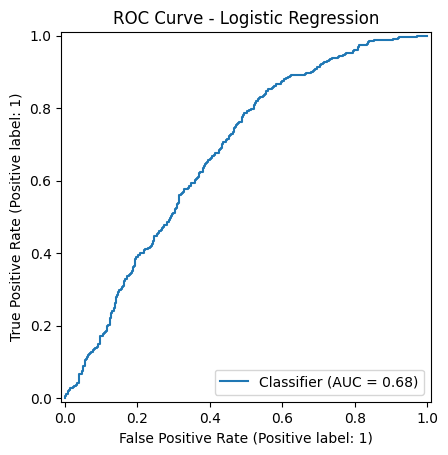

In [98]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    test_prob_final
)

plt.title("ROC Curve - Logistic Regression")
plt.show()


In [99]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(X_train, y_train)

gb_pred = gradient_boosting_model.predict(X_test)
gb_prob = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [100]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1:", f1_score(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_prob))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Accuracy: 0.6375510204081632
Precision: 0.5660377358490566
Recall: 0.4259634888438134
F1: 0.4861111111111111
ROC-AUC: 0.6843680377747481

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.78      0.72       732
         1.0       0.57      0.43      0.49       493

    accuracy                           0.64      1225
   macro avg       0.62      0.60      0.60      1225
weighted avg       0.63      0.64      0.63      1225


Confusion Matrix:
[[571 161]
 [283 210]]


In [101]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

param_grid_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search_gb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

In [102]:
print("Best Parameters:")
print(grid_search_gb.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search_gb.best_score_)

Best Parameters:
{'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 100}

Best CV ROC-AUC:
0.6871166410266287


In [103]:
best_gb_model = grid_search_gb.best_estimator_

best_gb_model.fit(X_train, y_train)

gb_test_pred = best_gb_model.predict(X_test)
gb_test_prob = best_gb_model.predict_proba(X_test)[:, 1]

In [104]:
print("Accuracy:", accuracy_score(y_test, gb_test_pred))
print("Precision:", precision_score(y_test, gb_test_pred))
print("Recall:", recall_score(y_test, gb_test_pred))
print("F1:", f1_score(y_test, gb_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, gb_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_test_pred))

Accuracy: 0.6236734693877551
Precision: 0.5544217687074829
Recall: 0.3306288032454361
F1: 0.4142312579415502
ROC-AUC: 0.6819433822143893

Classification Report:
              precision    recall  f1-score   support

         0.0       0.65      0.82      0.72       732
         1.0       0.55      0.33      0.41       493

    accuracy                           0.62      1225
   macro avg       0.60      0.58      0.57      1225
weighted avg       0.61      0.62      0.60      1225


Confusion Matrix:
[[601 131]
 [330 163]]


In [105]:
cv_probabilities_gb = cross_val_predict(
    best_gb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [106]:
thresholds = np.arange(0.20, 0.81, 0.01)

gb_threshold_results = []

for threshold in thresholds:
    cv_pred = (cv_probabilities_gb >= threshold).astype(int)

    gb_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_train, cv_pred),
        "recall": recall_score(y_train, cv_pred),
        "f1": f1_score(y_train, cv_pred),
    })

gb_threshold_df = pd.DataFrame(gb_threshold_results)

best_gb_threshold = gb_threshold_df.loc[
    gb_threshold_df["f1"].idxmax()
]

print(best_gb_threshold)

threshold    0.310000
precision    0.492218
recall       0.898073
f1           0.635907
Name: 11, dtype: float64


c:\Users\pedra\miniconda3\envs\ML_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pedra\miniconda3\envs\ML_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pedra\miniconda3\envs\ML_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pedr

In [107]:
best_gb_model.fit(X_train, y_train)

gb_test_prob_final = best_gb_model.predict_proba(X_test)[:, 1]

final_gb_threshold = 0.31

gb_test_pred_final = (
    gb_test_prob_final >= final_gb_threshold
).astype(int)

In [108]:
print("Accuracy:", accuracy_score(y_test, gb_test_pred_final))
print("Precision:", precision_score(y_test, gb_test_pred_final))
print("Recall:", recall_score(y_test, gb_test_pred_final))
print("F1:", f1_score(y_test, gb_test_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, gb_test_prob_final))

print("\nClassification Report:")
print(classification_report(y_test, gb_test_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_test_pred_final))

Accuracy: 0.5836734693877551
Precision: 0.49035187287173665
Recall: 0.8762677484787018
F1: 0.62882096069869
ROC-AUC: 0.6819433822143893

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.39      0.53       732
         1.0       0.49      0.88      0.63       493

    accuracy                           0.58      1225
   macro avg       0.66      0.63      0.58      1225
weighted avg       0.69      0.58      0.57      1225


Confusion Matrix:
[[283 449]
 [ 61 432]]


In [109]:
final_model = grid_search.best_estimator_

In [110]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [111]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = final_model.named_steps[
    "model"
].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df.head(15)

,feature,coefficient,abs_coefficient
5,num__BMXWT,0.901221,0.901221
0,num__RIDAGEYR,0.555557,0.555557
3,num__BMXBMI,-0.550801,0.550801
6,num__BMXHT,-0.493456,0.493456
14,cat__RIDRETH3_4.0,0.311183,0.311183
12,cat__RIDRETH3_2.0,-0.292974,0.292974
10,cat__RIAGENDR_2.0,-0.255842,0.255842
21,cat__DMDEDUC2_5.0,-0.231889,0.231889
9,cat__RIAGENDR_1.0,0.136899,0.136899
17,cat__DMDEDUC2_1.0,0.134991,0.134991


In [112]:
OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_ca

In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer_final = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer_final = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        ),
    ]
)

preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_final,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer_final,
            categorical_features
        ),
    ]
)

In [114]:
final_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_final),
        (
            "model",
            LogisticRegression(
                C=3,
                max_iter=1000
            )
        )
    ]
)

In [115]:
final_logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [116]:
final_pred = final_logistic_model.predict(X_test)
final_prob = final_logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1:", f1_score(y_test, final_pred))
print("ROC-AUC:", roc_auc_score(y_test, final_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))


Accuracy: 0.6342857142857142
Precision: 0.5644699140401146
Recall: 0.3995943204868154
F1: 0.4679334916864608
ROC-AUC: 0.6756281936177524

Confusion Matrix:
[[580 152]
 [296 197]]


In [117]:
from sklearn.model_selection import cross_val_predict

cv_probabilities_final = cross_val_predict(
    final_logistic_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [118]:
thresholds = np.arange(0.20, 0.81, 0.01)

final_threshold_results = []

for threshold in thresholds:
    cv_pred = (
        cv_probabilities_final >= threshold
    ).astype(int)

    final_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_train,
            cv_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_train,
            cv_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_train,
            cv_pred,
            zero_division=0
        )
    })

final_threshold_df = pd.DataFrame(
    final_threshold_results
)

best_final_threshold = final_threshold_df.loc[
    final_threshold_df["f1"].idxmax()
]

print(best_final_threshold)

threshold    0.280000
precision    0.488815
recall       0.897566
f1           0.632934
Name: 8, dtype: float64


In [119]:
final_model = final_logistic_model

final_model.fit(X_train, y_train)

final_test_prob = final_model.predict_proba(X_test)[:, 1]

final_threshold = 0.28

final_test_pred = (
    final_test_prob >= final_threshold
).astype(int)

In [120]:
print("Accuracy:", accuracy_score(y_test, final_test_pred))
print("Precision:", precision_score(y_test, final_test_pred))
print("Recall:", recall_score(y_test, final_test_pred))
print("F1:", f1_score(y_test, final_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, final_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, final_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_test_pred))

Accuracy: 0.5877551020408164
Precision: 0.4931972789115646
Recall: 0.8823529411764706
F1: 0.6327272727272727
ROC-AUC: 0.6756281936177524

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.39      0.53       732
         1.0       0.49      0.88      0.63       493

    accuracy                           0.59      1225
   macro avg       0.66      0.64      0.58      1225
weighted avg       0.69      0.59      0.57      1225


Confusion Matrix:
[[285 447]
 [ 58 435]]


In [121]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "logistic_regression_final.joblib"

joblib.dump(final_logistic_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ..\models\logistic_regression_final.joblib


In [122]:
import json

config = {
    "threshold": 0.28,
    "model_name": "Logistic Regression",
    "target": "high_bp"
}

config_path = MODEL_DIR / "model_config.json"

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"Config saved to: {config_path}")

Config saved to: ..\models\model_config.json


In [123]:
loaded_model = joblib.load(model_path)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [124]:
test_probability = loaded_model.predict_proba(
    X_test.iloc[:1]
)[:, 1][0]

test_prediction = int(
    test_probability >= 0.28
)

print("Probability:", test_probability)
print("Prediction:", test_prediction)

Probability: 0.513412088731267
Prediction: 1


In [125]:
features_v2 = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
    "DMDHHSIZ",
    "BMXBMI",
    "BMXWAIST",
    "BMXWT",
    "BMXHT",
    "SMQ020",
    "LBDHDD",
    "LBXVIDMS",
]

In [126]:
ml_df_v2 = base_lab[
    base_lab["high_bp"].notna()
][features_v2 + ["high_bp"]].copy()

print("Shape:", ml_df_v2.shape)
print("\nMissing values:")
print(ml_df_v2.isna().mean().sort_values(ascending=False))

Shape: (6123, 14)

Missing values:
LBDHDD      0.094888
LBXVIDMS    0.077740
DMDEDUC2    0.042953
DMDMARTZ    0.042626
BMXWAIST    0.033480
BMXBMI      0.010126
BMXWT       0.008003
BMXHT       0.006696
SMQ020      0.001470
RIAGENDR    0.000000
DMDHHSIZ    0.000000
RIDRETH3    0.000000
RIDAGEYR    0.000000
high_bp     0.000000
dtype: float64


In [127]:
X_v2 = ml_df_v2.drop(columns="high_bp")
y_v2 = ml_df_v2["high_bp"]

print("X shape:", X_v2.shape)
print("y shape:", y_v2.shape)

print("\nTarget distribution:")
print(y_v2.value_counts())

X shape: (6123, 13)
y shape: (6123,)

Target distribution:
high_bp
0.0    3658
1.0    2465
Name: count, dtype: int64


In [128]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

In [129]:
numeric_features_v2 = [
    "RIDAGEYR",
    "DMDHHSIZ",
    "BMXBMI",
    "BMXWAIST",
    "BMXWT",
    "BMXHT",
    "LBDHDD",
    "LBXVIDMS"
]

categorical_features_v2 = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTZ",
    "SMQ020"
]

In [130]:
numeric_transformer_v2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer_v2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ]
)

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_v2, numeric_features_v2),
        ("cat", categorical_transformer_v2, categorical_features_v2),
    ]
)

In [131]:
logistic_model_v2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        ("model", LogisticRegression(
            C=3,
            max_iter=1000
        ))
    ]
)

In [132]:
logistic_model_v2.fit(X_train_v2, y_train_v2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [133]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_prob_v2 = logistic_model_v2.predict_proba(X_test_v2)[:, 1]
y_pred_v2 = (y_prob_v2 >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test_v2, y_pred_v2))
print("Precision:", precision_score(y_test_v2, y_pred_v2))
print("Recall   :", recall_score(y_test_v2, y_pred_v2))
print("F1       :", f1_score(y_test_v2, y_pred_v2))
print("ROC-AUC  :", roc_auc_score(y_test_v2, y_prob_v2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v2, y_pred_v2))

Accuracy : 0.6334693877551021
Precision: 0.564327485380117
Recall   : 0.39148073022312374
F1       : 0.4622754491017964
ROC-AUC  : 0.676800341391503

Confusion Matrix:
[[583 149]
 [300 193]]


In [134]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probabilities_v2 = cross_val_predict(
    logistic_model_v2,
    X_train_v2,
    y_train_v2,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [135]:
thresholds = np.arange(0.20, 0.51, 0.01)

threshold_results_v2 = []

for threshold in thresholds:
    y_pred = (oof_probabilities_v2 >= threshold).astype(int)

    precision = precision_score(
        y_train_v2,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_train_v2,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_train_v2,
        y_pred,
        zero_division=0
    )

    threshold_results_v2.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results_v2 = pd.DataFrame(threshold_results_v2)

threshold_results_v2.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
9,0.29,0.494048,0.883874,0.633818
8,0.28,0.489886,0.896552,0.633578
10,0.30,0.497368,0.862576,0.630935
7,0.27,0.483374,0.906694,0.630577
6,0.26,0.478042,0.916329,0.628303
11,0.31,0.499102,0.845842,0.627776
5,0.25,0.473277,0.929513,0.627203
12,0.32,0.502759,0.831643,0.626672
4,0.24,0.468742,0.939148,0.625359
13,0.33,0.506126,0.816937,0.625024


In [136]:
final_threshold_v2 = 0.29

y_prob_test_v2 = logistic_model_v2.predict_proba(X_test_v2)[:, 1]

y_pred_test_v2 = (
    y_prob_test_v2 >= final_threshold_v2
).astype(int)

In [137]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Threshold:", final_threshold_v2)

print("Accuracy :", accuracy_score(y_test_v2, y_pred_test_v2))
print("Precision:", precision_score(y_test_v2, y_pred_test_v2))
print("Recall   :", recall_score(y_test_v2, y_pred_test_v2))
print("F1       :", f1_score(y_test_v2, y_pred_test_v2))
print("ROC-AUC  :", roc_auc_score(y_test_v2, y_prob_test_v2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v2, y_pred_test_v2))

print("\nClassification Report:")
print(classification_report(
    y_test_v2,
    y_pred_test_v2,
    zero_division=0
))

Threshold: 0.29
Accuracy : 0.6
Precision: 0.5017502917152858
Recall   : 0.8722109533468559
F1       : 0.6370370370370371
ROC-AUC  : 0.676800341391503

Confusion Matrix:
[[305 427]
 [ 63 430]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.42      0.55       732
         1.0       0.50      0.87      0.64       493

    accuracy                           0.60      1225
   macro avg       0.67      0.64      0.60      1225
weighted avg       0.70      0.60      0.59      1225



In [138]:
import joblib
import json
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

final_model_path = MODEL_DIR / "logistic_regression_final.joblib"

joblib.dump(
    logistic_model_v2,
    final_model_path
)

print(f"Model saved to: {final_model_path}")

Model saved to: ..\models\logistic_regression_final.joblib


In [139]:
final_config = {
    "threshold": 0.29,
    "model_name": "Logistic Regression",
    "target": "high_bp",
    "features": [
        "RIDAGEYR",
        "RIAGENDR",
        "RIDRETH3",
        "DMDEDUC2",
        "DMDMARTZ",
        "DMDHHSIZ",
        "BMXBMI",
        "BMXWAIST",
        "BMXWT",
        "BMXHT",
        "SMQ020",
        "LBDHDD",
        "LBXVIDMS"
    ]
}

config_path = MODEL_DIR / "model_config.json"

with open(config_path, "w") as f:
    json.dump(final_config, f, indent=4)

print(f"Config saved to: {config_path}")

Config saved to: ..\models\model_config.json


In [140]:
loaded_model = joblib.load(final_model_path)

with open(config_path, "r") as f:
    loaded_config = json.load(f)

print(type(loaded_model))
print(loaded_config)

<class 'sklearn.pipeline.Pipeline'>
{'threshold': 0.29, 'model_name': 'Logistic Regression', 'target': 'high_bp', 'features': ['RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTZ', 'DMDHHSIZ', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT', 'SMQ020', 'LBDHDD', 'LBXVIDMS']}
